# Tutorial 3: Pressure Results And Substrate Demos

Tutorial 1 built a single subjective trajectory. Tutorial 2 compared trajectories. This tutorial explains the pressure-result stack: what the result ladder claims, which evidence is strong or weak, and how the same APIs produce small demo artifacts.

The working thesis is:

```text
capacity + pressure -> useful mathematical function
```

The important distinction in this notebook is:

```text
committed result-ladder checks = current evidence snapshot
small live cells = API demos and artifact generation
```

The notebook should therefore be read as a results walkthrough with runnable demonstrations, not as a full recomputation of every compact sweep. See the [scope note](../../docs/orientation/scope_note.md) for what these experiments do and do not license.


## 0. Setup

Generated tutorial artifacts go under `out/tutorials/03_pressures_cavenet_evolved_subjects/`. The committed result snapshot is read from `results/result_ladder/`.


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import numpy as np
import matplotlib.pyplot as plt

try:
    from IPython.display import Image, Markdown, display
except Exception:
    def display(value):
        print(value)

    class Markdown(str):
        pass

    class Image:
        def __init__(self, filename: str, width: int | None = None):
            self.filename = filename
            self.width = width


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "cave").exists() and (candidate / "notebooks").exists():
            return candidate
    return start

ROOT = find_repo_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT = ROOT / "out" / "tutorials" / "03_pressures_cavenet_evolved_subjects"
OUT.mkdir(parents=True, exist_ok=True)


def show_artifact(path: Path, width: int = 780) -> None:
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"**Missing artifact:** `{path}`"))


def markdown_table(headers: list[str], rows: list[list[object]]) -> None:
    lines = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    for row in rows:
        lines.append("| " + " | ".join(str(item) for item in row) + " |")
    display(Markdown("\n".join(lines)))

RESULT_LADDER = ROOT / "results" / "result_ladder"
CHECKS = RESULT_LADDER / "checks"


def load_result_check(name: str) -> dict[str, object]:
    return json.loads((CHECKS / f"{name}.json").read_text(encoding="utf-8"))


def result_extra(name: str, index: int = 0) -> dict[str, object]:
    return load_result_check(name)["extra"][index]


def fmt(value: object, digits: int = 4) -> str:
    if isinstance(value, bool):
        return "pass" if value else "fail"
    if isinstance(value, int):
        return str(value)
    if isinstance(value, float):
        return f"{value:.{digits}g}"
    return str(value)


## 1. What Counts As A Pressure Result

The pressure program treats Cave roles as operational reference functions:

| Pressure | Capacity | Reference function | Observable effect |
| --- | --- | --- | --- |
| temporal recurrence | state retention | expectation | surprise drops over repeated structure |
| limited access | selective update | selection | diagnostic input survives bottleneck |
| delayed value | state/value coupling | value retention | useful state is retained over neutral state |
| future coupling | action/exposure output | regulation | state changes future sampling or exposure |
| repeated trajectories | latent/state geometry | topology-like organization | trajectories separate/converge under controls |

A result is strongest when it survives controls or population variation. Single episodes are useful for seeing the mechanism, but the evidence lives in result-ladder checks.


In [ ]:
index = json.loads((RESULT_LADDER / "index.json").read_text(encoding="utf-8"))
entries = {entry["id"]: entry for entry in index["entries"]}

selected = [
    "cavenet-ablation",
    "cavenet-pressure-population",
    "cavenet-controller-population",
    "cavenet-controller-learning",
    "evolved-exposure-sweep",
    "evolved-roles-sweep",
    "evolved-dissociation",
]

markdown_table(
    ["entry", "tier", "status", "claim"],
    [
        [
            entry_id,
            entries[entry_id]["tier"],
            "pass" if entries[entry_id]["ok"] else "fail",
            entries[entry_id]["claim"],
        ]
        for entry_id in selected
    ],
)

provenance = index["provenance"]
markdown_table(
    ["field", "value"],
    [
        ["generated at", provenance["generated_at"]],
        ["git sha", provenance["git"]["sha"][:10]],
        ["dirty tree", provenance["git"]["dirty"]],
        ["config", provenance["config_sha256"]],
    ],
)


## 2. CaveNet: Compatibility, Pressure, And Controllers

`CaveNet` is a network-form implementation of the Cave update path. `CaveNetConfig` exposes gains for attention, state input, expectation, surprise, learning, and topology.

The key result is not merely that one adaptive run changes gains. The ladder asks three separable questions:

- Can CaveNet express the reference roles? (`cavenet-ablation`)
- Does a simple pressure rule improve weak CaveNet across generated worlds? (`cavenet-pressure-population`)
- Does a latent controller produce a stronger, more consistent gain policy? (`cavenet-controller-population` and `cavenet-controller-learning`)


### CaveNet Result Snapshot

The simple pressure policy passes, but weakly. The latent controller is the stronger CaveNet result. The plastic readout result is positive, but more modest than the full controller.


In [ ]:
pressure_population = result_extra("cavenet-pressure-population")
controller_population = result_extra("cavenet-controller-population")
controller_learning = result_extra("cavenet-controller-learning")
ablation = result_extra("cavenet-ablation")

pp = pressure_population["roles"]["population_recovery"]
cp = controller_population["roles"]["population_recovery"]
cl = controller_learning["roles"]["learned_recovery"]

markdown_table(
    ["result", "improved", "mean improvement", "interpretation"],
    [
        [
            "pressure rule",
            f"{pp['improved_sequence_count']}/{pp['sequence_count']}",
            fmt(pp["mean_distance_improvement"]),
            "passes, but the average movement is tiny",
        ],
        [
            "latent controller",
            f"{cp['improved_sequence_count']}/{cp['sequence_count']}",
            fmt(cp["mean_distance_improvement"]),
            "stronger and consistent across this compact population",
        ],
        [
            "plastic readout",
            f"{cl['improved_over_static_count']}/{cl['sequence_count']} over static",
            fmt(cl["mean_distance_improvement_over_static"]),
            "positive learned-readout gain, but modest",
        ],
    ],
)

markdown_table(
    ["CaveNet role check", "readout", "value"],
    [
        ["ablation", "zero attention actual mass", fmt(ablation["roles"]["attention_gate"]["zero_attention_actual_mass"])],
        ["ablation", "zero expectation expected mass", fmt(ablation["roles"]["expectation_readout"]["zero_expectation_expected_mass"])],
        ["ablation", "zero learning final memory", fmt(ablation["roles"]["memory_cell"]["zero_learning_final_memory_mass"])],
        ["ablation", "zero topology mass", fmt(ablation["roles"]["topology_layer"]["zero_topology_mass"])],
    ],
)

markdown_table(
    ["controller population readout", "value"],
    [
        ["mean fixed weak distance", fmt(cp["mean_fixed_weak_distance"])],
        ["mean controller distance", fmt(cp["mean_controller_distance"])],
        ["mean memory-distance improvement", fmt(cp["mean_memory_distance_improvement"])],
        ["mean external-attention gain drop without attention capacity", fmt(controller_population["roles"]["input_ablation_effects"]["mean_external_attention_gain_drop_without_attention_capacity"])],
    ],
)


### Single-Run CaveNet Pressure Demo

This live cell shows the mechanism on one authored sequence: weak gains start low, the adaptive policy moves them, and the resulting episode can still be rendered and compared. This is a demo of the machinery; the population table above is the result claim.


In [ ]:
from cave.pressure.tests.cavenet_pressure import build_pressure_episode, check_cavenet_pressure
from cave.observation.episode_runs import episode_set, labeled_episode
from cave.presentation.renderers.episode_set_dashboard import save_episode_set_dashboard, save_episode_set_distances_json

DT = 0.2
pressure_episodes = {
    variant: build_pressure_episode(variant, dt=DT)
    for variant in ("fixed-weak", "adaptive", "fixed-reference")
}
pressure_check = check_cavenet_pressure(dt=DT)

markdown_table(
    ["variant", "initial attention", "final attention", "initial learning", "final learning", "topology mass"],
    [
        [
            variant,
            f"{episode.metadata['cavenet_initial_config']['attention_gain']:.3f}",
            f"{episode.metadata['cavenet_config']['attention_gain']:.3f}",
            f"{episode.metadata['cavenet_initial_config']['learning_rate_gain']:.3f}",
            f"{episode.metadata['cavenet_config']['learning_rate_gain']:.3f}",
            f"{episode.metadata['cavenet_final_topology_mass']:.2f}",
        ]
        for variant, episode in pressure_episodes.items()
    ],
)

roles = pressure_check["roles"]
markdown_table(
    ["role readout", "value"],
    [
        ["adaptive config delta", f"{roles['pressure_response']['adaptive_config_delta']:.4f}"],
        ["fixed weak config delta", f"{roles['pressure_response']['fixed_weak_config_delta']:.4f}"],
        ["distance improvement", f"{roles['reference_closeness']['distance_improvement']:.4f}"],
        ["adaptive memory mass", f"{roles['functional_recovery']['adaptive_memory_mass']:.4f}"],
        ["fixed weak memory mass", f"{roles['functional_recovery']['fixed_weak_memory_mass']:.4f}"],
        ["check ok", pressure_check["ok"]],
    ],
)

### CaveNet Comparison Dashboard

The same dashboard machinery from Tutorial 2 compares fixed weak, adaptive weak, and fixed reference CaveNet runs.

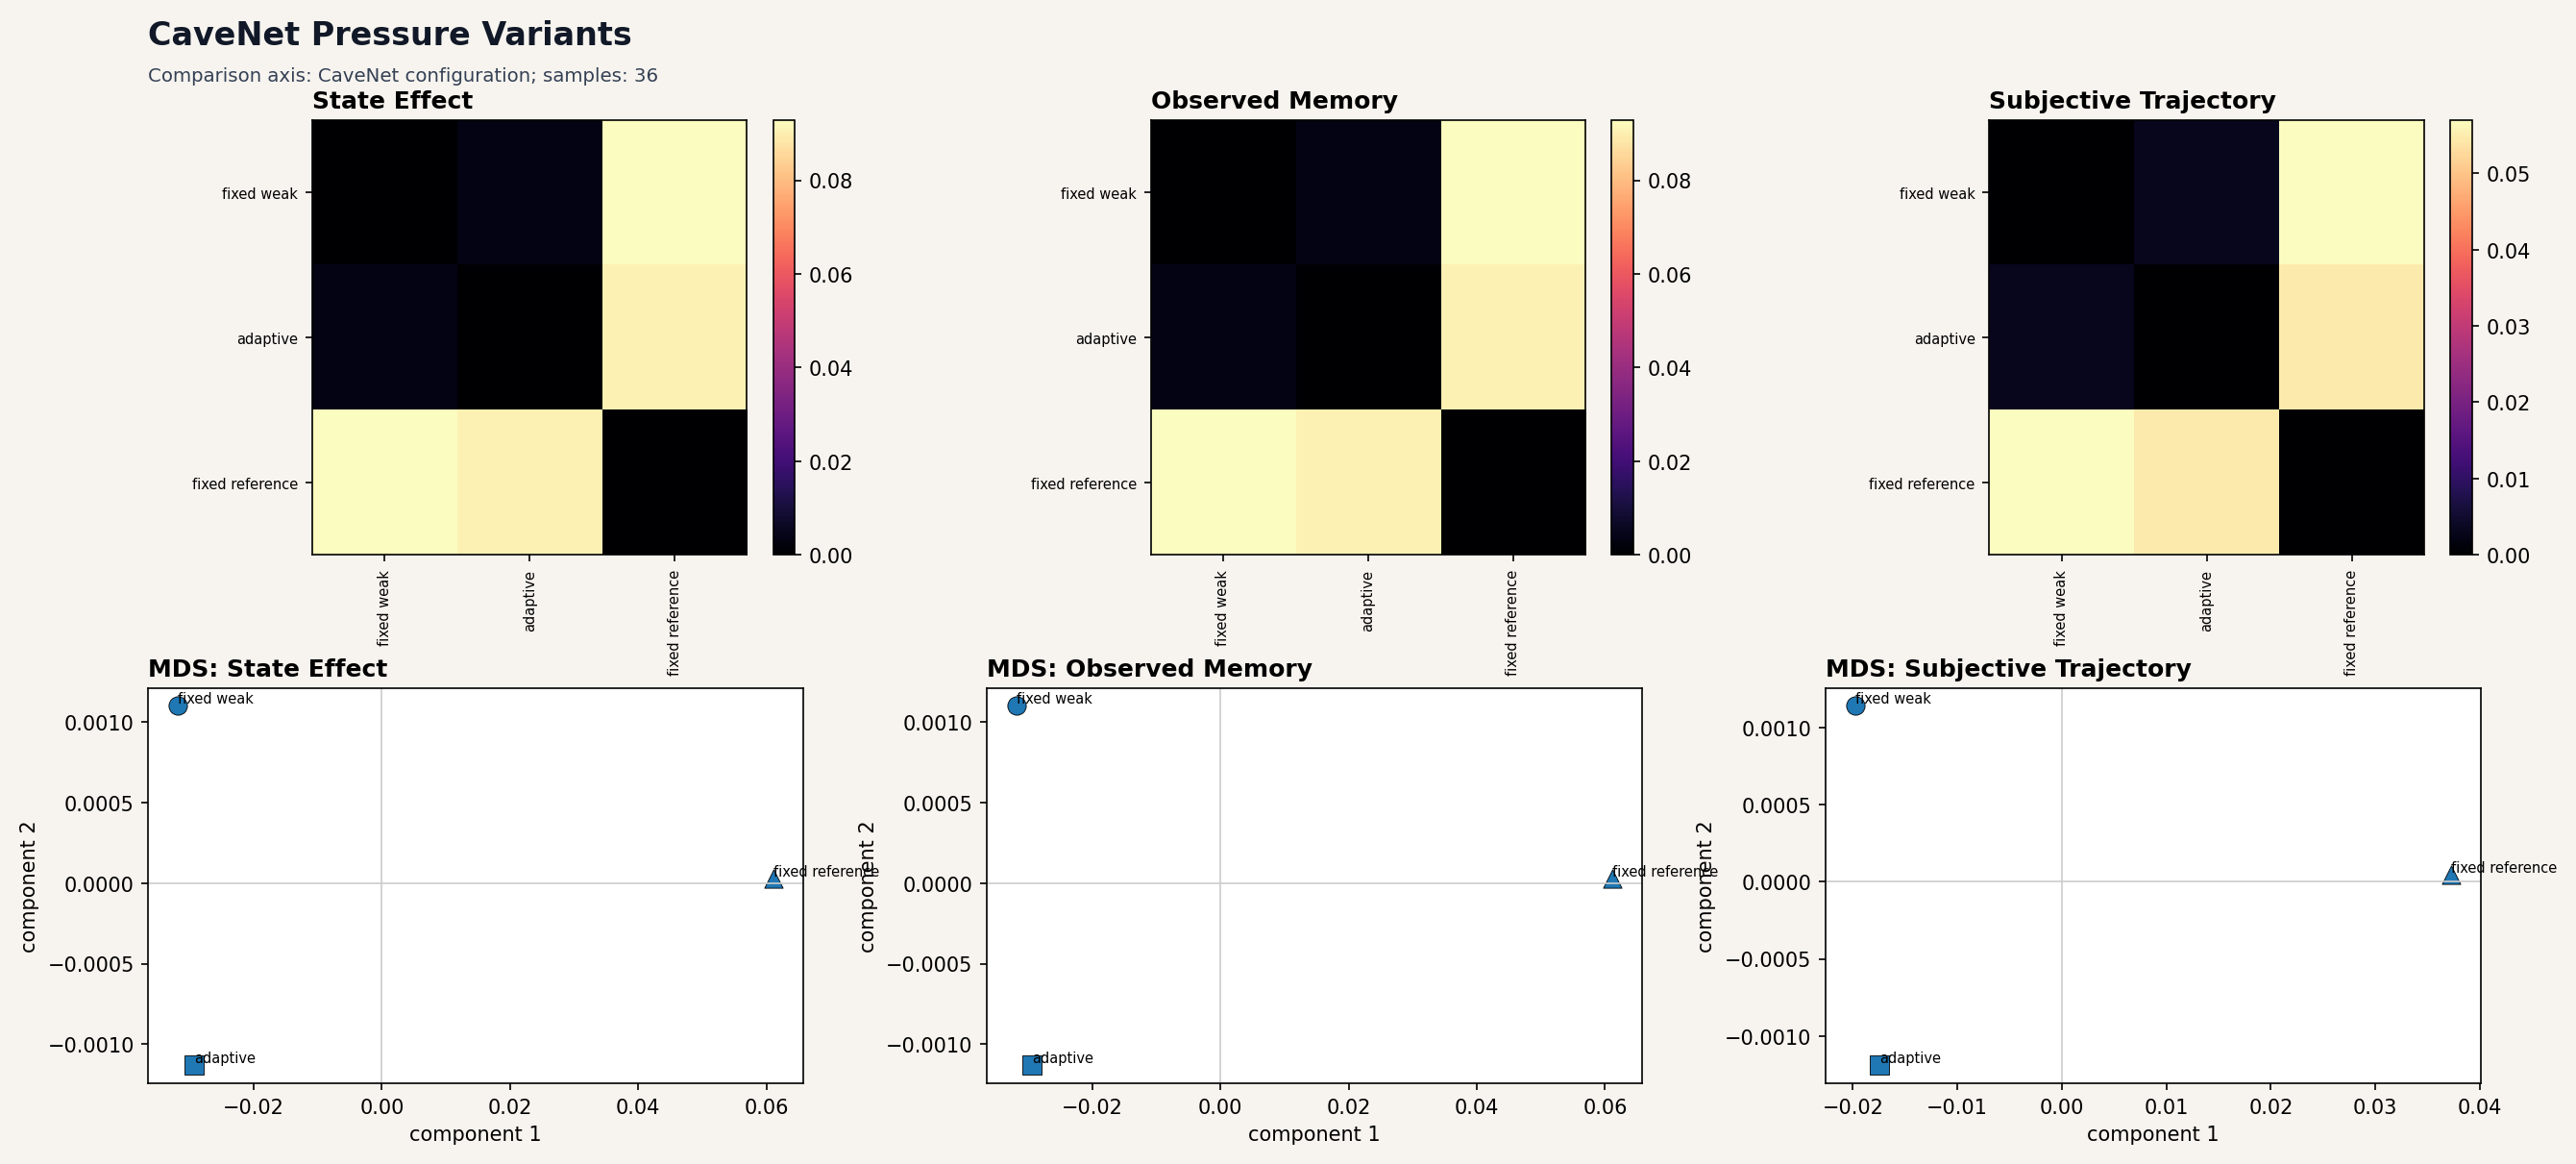

In [3]:
pressure_set = episode_set(
    [
        labeled_episode(episode, id=variant, label=variant.replace("-", " "), group="cavenet")
        for variant, episode in pressure_episodes.items()
    ],
    id="cavenet_pressure_variants",
    title="CaveNet Pressure Variants",
    comparison_axis="CaveNet configuration",
)

pressure_dashboard = OUT / "01_cavenet_pressure_dashboard.png"
pressure_distances = OUT / "01_cavenet_pressure_distances.json"
save_episode_set_dashboard(pressure_set, pressure_dashboard, samples=36)
save_episode_set_distances_json(pressure_set, pressure_distances, samples=36)
show_artifact(pressure_dashboard, width=980)

### Adaptive Config History

The adaptive run stores `cavenet_config_history` in episode metadata. This is the parameter-development trace.

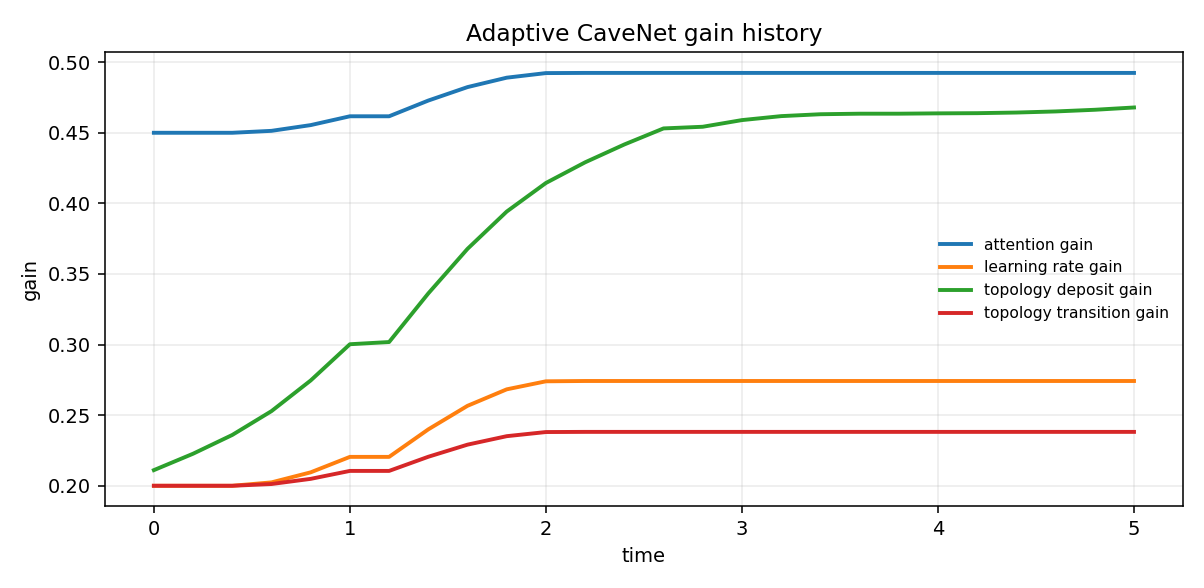

In [4]:
def plot_cavenet_config_history(episode, output: Path) -> Path:
    history = episode.metadata.get("cavenet_config_history", [])
    times = np.array([entry["t"] for entry in history], dtype=float)
    keys = ["attention_gain", "learning_rate_gain", "topology_deposit_gain", "topology_transition_gain"]
    fig, ax = plt.subplots(figsize=(8.6, 4.2))
    for key in keys:
        values = np.array([entry["after"][key] for entry in history], dtype=float)
        ax.plot(times, values, linewidth=2.0, label=key.replace("_", " "))
    ax.set_title("Adaptive CaveNet gain history")
    ax.set_xlabel("time")
    ax.set_ylabel("gain")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=8)
    fig.tight_layout()
    fig.savefig(output, dpi=140)
    plt.close(fig)
    return output

config_history_png = plot_cavenet_config_history(pressure_episodes["adaptive"], OUT / "02_cavenet_config_history.png")
show_artifact(config_history_png, width=820)

## 3. Role Recovery Matrix

The role recovery matrix aggregates separate pressure/control reports. It is not a new behavior run; it is a compact status board over expectation, selection, value retention, regulation, and topology recovery checks.

| role | status | example margin | value |
| --- | --- | --- | --- |
| expectation | pass | cavenet_surprise_drop_gain | 0.0027 |
| selection | pass | cavenet_selection_margin | 0.2000 |
| value_retention | pass | valued_focus_margin | 0.8414 |
| regulation | pass | cave_audio_delta | 0.2872 |
| topology | pass | cavenet_topology_mass_gain | 70.1918 |

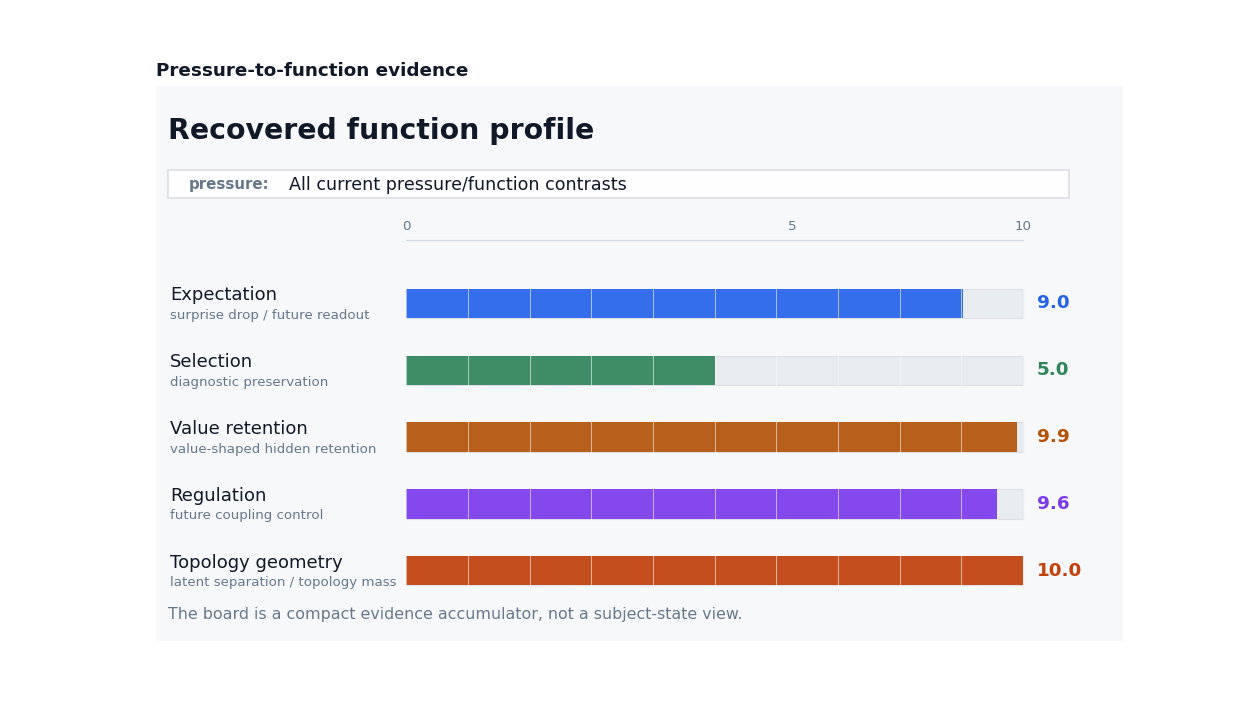

In [6]:
from cave.pressure.tests.role_recovery_matrix import check_role_recovery_matrix, write_role_recovery_matrix_json
from cave.presentation.renderers.matplotlib_renderer.role_evidence import save_role_evidence_frame

role_matrix = check_role_recovery_matrix(dt=1.0)
role_json = OUT / "04_role_recovery_matrix.json"
write_role_recovery_matrix_json(role_json, dt=1.0)
role_board = OUT / "05_role_evidence_board.png"
save_role_evidence_frame(role_board, matrix_result=role_matrix, dt=1.0)

role_rows = []
for role, status in role_matrix["matrix"].items():
    margins = status.get("margins", {})
    metric, value = next(iter(margins.items())) if margins else ("", 0.0)
    role_rows.append([role, status["status"], metric, f"{float(value):.4f}"])

markdown_table(
    ["role", "status", "example margin", "value"],
    role_rows,
)
show_artifact(role_board, width=880)

## 4. Evolved Recurrent Subject

The evolved subject is deliberately not CaveNet. It has hidden state and exposure output, but no native Cave expectation variable, prediction loss, explicit memory trace, or topology layer.

This is the stronger non-reference case in the current ladder. The committed results ask whether delayed value/exposure pressure selects hidden state that carries future outcome information and regulates exposure, and whether the readouts survive sweeps and controls.


### Evolved Result Snapshot

These rows read the committed result-ladder checks. They are the evidence snapshot; the compact live demo below is only a smaller API demonstration.


In [ ]:
exposure = result_extra("evolved-exposure")
exposure_sweep = result_extra("evolved-exposure-sweep")
roles_sweep = result_extra("evolved-roles-sweep")
dissociation = result_extra("evolved-dissociation")

exposure_roles = exposure["roles"]
exposure_sweep_roles = exposure_sweep["roles"]
role_sweep_roles = roles_sweep["roles"]
dissociation_roles = dissociation["roles"]

markdown_table(
    ["result", "readout", "value", "interpretation"],
    [
        ["single evolved run", "exposure contrast", fmt(exposure_roles["exposure_regulation"]["evolved_exposure_contrast"]), "opens for good and closes for bad"],
        ["single evolved run", "future probe accuracy", fmt(exposure_roles["latent_expectation_probe"]["evolved_probe_accuracy"]), "future outcome is readable from hidden state"],
        ["exposure sweep", "strict pass rate", fmt(exposure_sweep_roles["robust_expectation_regulation"]["strict_pass_rate"]), "compact seed sweep passes 4/5 strict checks"],
        ["roles sweep", "median probe accuracy", fmt(role_sweep_roles["value_retention"]["median_probe_accuracy"]), "value retention is robust"],
        ["roles sweep", "cue-weight concentration pass count", f"{role_sweep_roles['selection_like_readout']['cue_total_pass_count']}/5", "selection evidence is weaker and bounded"],
        ["dissociation", "gain over frequency counter", fmt(dissociation_roles["value_retention"]["utility_gain_over_frequency_counter"]), "beats a frequency-counting shortcut"],
    ],
)

markdown_table(
    ["boundary", "value"],
    [
        ["dynamic attention claimed", role_sweep_roles["attention_claim_boundary"]["dynamic_attention_claimed"]],
        ["future allocation claimed", role_sweep_roles["attention_claim_boundary"]["future_allocation_claimed"]],
        ["internal expectation channel claimed", role_sweep_roles["attention_claim_boundary"]["internal_expectation_channel_claimed"]],
        ["selection metric", role_sweep_roles["attention_claim_boundary"]["selection_metric"]],
    ],
)


### Compact Evolved Exposure Demo

This cell reruns a smaller evolved-exposure configuration so the API is visible in the notebook. Use the committed sweep rows above for the current result claim.


In [ ]:
from cave.pressure.tests.evolved_exposure import (
    EVOLVED_EXPOSURE_VARIANTS,
    build_evolved_exposure_episode,
    check_evolved_exposure,
)
from cave.substrates.evolved_subject import evolved_behavior_metrics, latent_future_outcome_accuracy

EVOLVED_KWARGS = dict(generations=12, population_size=20, world_count=8, evaluation_cycles=12, seed=17)

evolved_episodes = {
    variant: build_evolved_exposure_episode(variant, **EVOLVED_KWARGS)
    for variant in EVOLVED_EXPOSURE_VARIANTS
}
evolved_check = check_evolved_exposure(**EVOLVED_KWARGS)

markdown_table(
    ["variant", "utility", "good exposure", "bad exposure", "contrast", "future probe"],
    [
        [
            variant,
            f"{evolved_behavior_metrics(episode)['utility']:.3f}",
            f"{evolved_behavior_metrics(episode)['good_exposure']:.3f}",
            f"{evolved_behavior_metrics(episode)['bad_exposure']:.3f}",
            f"{evolved_behavior_metrics(episode)['exposure_contrast']:.3f}",
            f"{latent_future_outcome_accuracy(episode):.3f}",
        ]
        for variant, episode in evolved_episodes.items()
    ],
)
markdown_table(
    ["check", "value"],
    [["ok", evolved_check["ok"]], ["errors", evolved_check["errors"]]],
)

### Evolved Control Metrics

This plot summarizes the utility and exposure contrast across evolved and control variants.

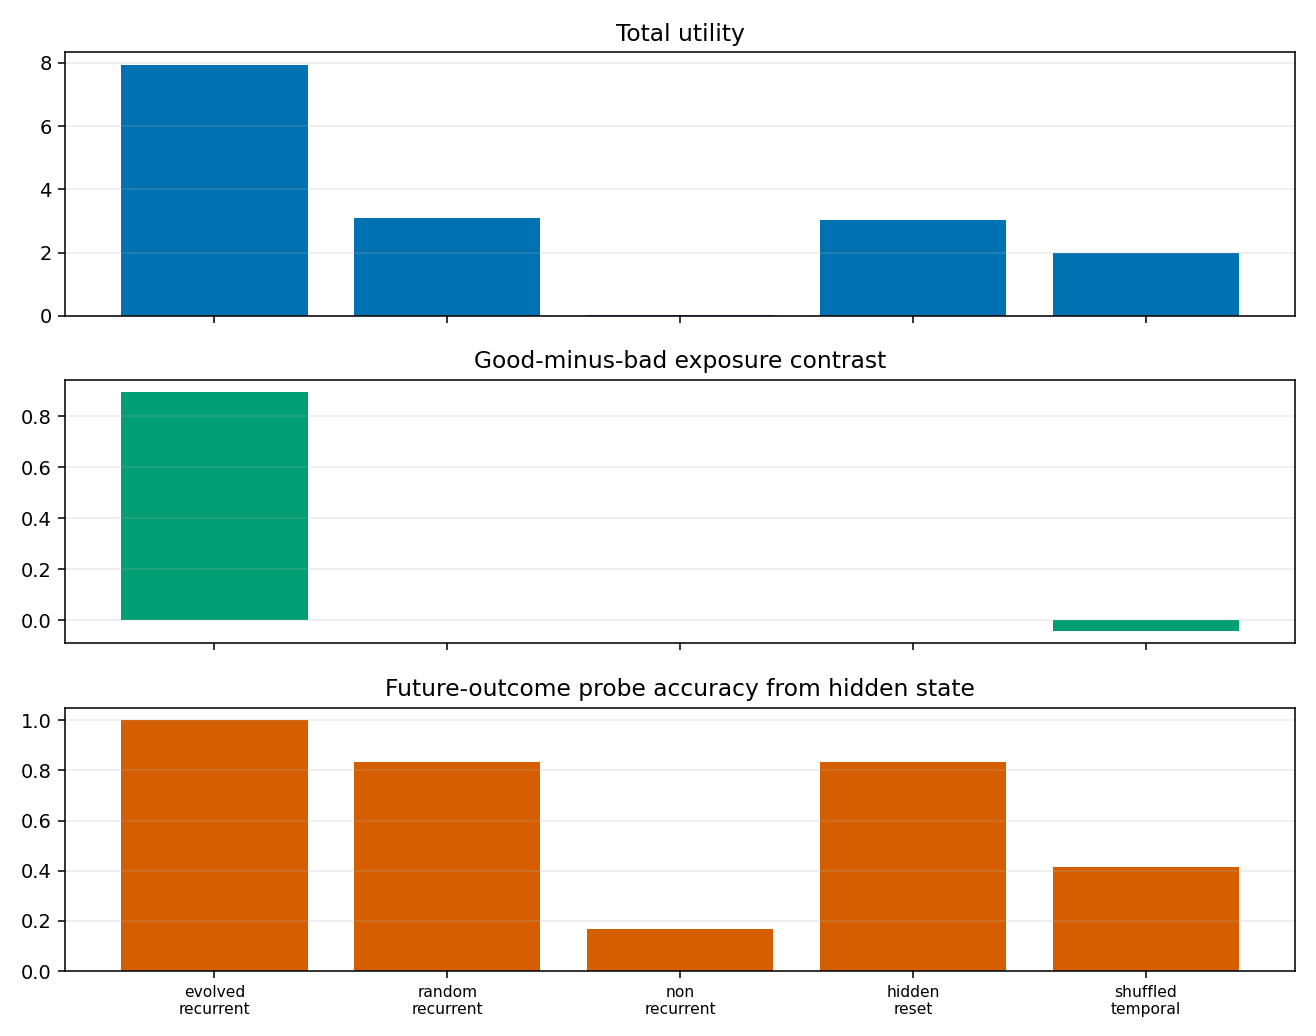

In [8]:
def plot_evolved_metrics(episodes: dict[str, object], output: Path) -> Path:
    variants = list(episodes)
    utilities = [evolved_behavior_metrics(episodes[v])["utility"] for v in variants]
    contrasts = [evolved_behavior_metrics(episodes[v])["exposure_contrast"] for v in variants]
    probes = [latent_future_outcome_accuracy(episodes[v]) for v in variants]
    x = np.arange(len(variants))
    fig, axes = plt.subplots(3, 1, figsize=(9.4, 7.4), sharex=True)
    axes[0].bar(x, utilities, color="#0072B2")
    axes[0].set_title("Total utility")
    axes[1].bar(x, contrasts, color="#009E73")
    axes[1].set_title("Good-minus-bad exposure contrast")
    axes[2].bar(x, probes, color="#D55E00")
    axes[2].set_title("Future-outcome probe accuracy from hidden state")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([v.replace("-", "\n") for v in variants], fontsize=8)
    for ax in axes:
        ax.grid(True, axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(output, dpi=140)
    plt.close(fig)
    return output

evolved_metrics_png = plot_evolved_metrics(evolved_episodes, OUT / "06_evolved_exposure_metrics.png")
show_artifact(evolved_metrics_png, width=860)

## 5. Frequency/Value Dissociation

The first evolved exposure world aligns frequency, value, and temporal adjacency enough that a cheap strategy could look better than it is. The harder dissociation world breaks those shortcuts: rare cues carry the real outcome, common cues are signed but low-value, and the delay is filled with distractors.

The full suite result is committed under `results/result_ladder/checks/` so this tutorial can read the publication-scale check without rerunning the genetic search. To recompute it, call `check_evolved_dissociation()` from `cave.pressure.tests.evolved_dissociation`.


In [ ]:
dissociation_check = result_extra("evolved-dissociation")
roles = dissociation_check["roles"]

markdown_table(
    ["readout", "value"],
    [
        ["ok", dissociation_check["ok"]],
        ["rare future accuracy", f"{roles['value_retention']['rare_future_accuracy']:.3f}"],
        ["evolved utility", f"{roles['value_retention']['evolved_utility']:.3f}"],
        ["frequency-counter utility", f"{roles['value_retention']['frequency_counter_utility']:.3f}"],
        ["gain over frequency counter", f"{roles['value_retention']['utility_gain_over_frequency_counter']:.3f}"],
        ["rare exposure contrast", f"{roles['exposure_regulation']['rare_exposure_contrast']:.3f}"],
        ["reset rare contrast", f"{roles['control_collapse']['reset_rare_contrast']:.3f}"],
        ["non-recurrent rare accuracy", f"{roles['control_collapse']['nonrecurrent_rare_accuracy']:.3f}"],
        ["shuffled rare accuracy", f"{roles['control_collapse']['shuffled_rare_accuracy']:.3f}"],
        ["common exposure contrast", f"{roles['magnitude_selectivity']['common_exposure_contrast']:.3f}"],
    ],
)
markdown_table(
    ["check", "value"],
    [["errors", dissociation_check["errors"]]],
)


## 6. Cross-Substrate Comparison Demo

Even though CaveNet and evolved subjects have different internal mechanisms, both become `Episode`s. That lets us use the same comparison tools while keeping the interpretive boundary clear.

This dashboard is a surface-comparison demo, not evidence of coordinate identity. The valid comparison is functional resemblance under a shared episode contract.


In [ ]:
from cave.presentation.renderers.episode_set_dashboard import save_episode_set_dashboard

cross_set = episode_set(
    [
        labeled_episode(pressure_episodes["fixed-reference"], id="cavenet-reference", label="CaveNet reference", group="cavenet"),
        labeled_episode(pressure_episodes["adaptive"], id="cavenet-adaptive", label="CaveNet adaptive", group="cavenet"),
        labeled_episode(evolved_episodes["evolved-recurrent"], id="evolved-recurrent", label="evolved recurrent", group="evolved"),
        labeled_episode(evolved_episodes["hidden-reset"], id="hidden-reset", label="hidden reset", group="control"),
    ],
    id="cross_substrate_tutorial",
    title="Cross-Substrate Episode Comparison",
    comparison_axis="substrate / control",
)

cross_dashboard = OUT / "08_cross_substrate_dashboard.png"
save_episode_set_dashboard(cross_set, cross_dashboard, samples=24)
show_artifact(cross_dashboard, width=980)

## 7. What This Tutorial Establishes

This notebook is the results-facing companion to the first two tutorials:

- Result-ladder checks are the current evidence snapshot.
- Single-run CaveNet cells demonstrate gain movement and artifact generation, but the simple pressure result is weak at population scale.
- CaveNet ablations show role compatibility; the latent controller is the stronger CaveNet pressure-shaped result.
- Evolved recurrent subjects are the stronger non-reference case because the named Cave roles are not installed directly.
- Evolved selection evidence is deliberately bounded: cue-weight concentration is shown, not full dynamic attention or an internal expectation channel.
- Cross-substrate dashboards are useful comparison surfaces, but they should be read as functional resemblance rather than shared coordinates.

Together, the three tutorials now move from one trajectory, to trajectory comparison, to result-ladder interpretation with runnable pressure demos.
